## Building a Conversational Chatbot with LangGraph

The workflows covered so far in this repo run once: a fixed input goes in, a sequence of nodes processes it, a final output comes out. A chatbot is different — it needs to hold a running conversation, where each new turn depends on everything said before it. This notebook builds the simplest version of that pattern in LangGraph.

**The core problem: state that accumulates instead of state that gets overwritten**

In the earlier sequential workflows, each node wrote a key into the state dictionary and the next node read it, typically replacing whatever was there before. A conversation cannot work that way — every new message must be added to the history, not replace it. LangGraph solves this with a **reducer function** attached to a state field via `Annotated`. Instead of the default "last write wins" behavior, a field annotated with a reducer merges new values into the existing ones according to that reducer's logic. For a conversation, the reducer used is `add_messages`, and the field is a list of message objects. Every time a node returns `{'messages': [...]}`, those messages are appended to the list already in state rather than replacing it.

**The single LLM node**

The graph itself is minimal: one node wraps a call to the chat model. That node receives the *entire* accumulated message list from state (not just the newest message), passes it to `llm.invoke(...)`, and returns the model's reply. Because the node always sees the full history, the model has access to everything said earlier in the conversation — this is what makes multi-turn context possible with only one node and no explicit branching logic.

**Driving the conversation**

A `while` loop outside the graph repeatedly takes user input, wraps it in a `HumanMessage`, and invokes the compiled graph. Each invocation adds the new human message and the resulting AI message to the state's message list, so the next iteration's `llm.invoke` sees the whole exchange so far.

**What is missing here**

This notebook uses a `MemorySaver` checkpointer and a `thread_id`, which lets the message history persist *within* a single running Python process (the `while` loop), across multiple `invoke` calls tied to that thread. What it does not address is persistence *across sessions* — if the kernel restarts or the process ends, the conversation history tied to that `thread_id` is gone, because `MemorySaver` keeps everything in memory only. Durable, cross-session persistence (e.g., saving checkpoints to disk or a database so a conversation can be resumed after a restart) is the subject of the next notebook, `10_persistence.ipynb`.


### Imports

This cell pulls in everything the rest of the notebook needs:

- `StateGraph`, `START`, `END` from `langgraph.graph` — the graph builder and its fixed entry/exit markers.
- `TypedDict`, `Annotated` from `typing` — used to define the state schema and to attach a reducer to a field.
- `BaseMessage`, `HumanMessage` from `langchain_core.messages` — the message object types; `BaseMessage` is the general type used in the state annotation, `HumanMessage` is the concrete type used to wrap user input.
- `ChatOpenAI` from `langchain_openai` — the chat model that will be invoked inside the graph's node.
- `MemorySaver` from `langgraph.checkpoint.memory` — an in-memory checkpointer that lets the graph retain state across multiple `invoke` calls associated with the same thread.


In [3]:
from langgraph.graph import StateGraph, START, END
from typing import TypedDict, Annotated
from langchain_core.messages import BaseMessage, HumanMessage
from langchain_openai import ChatOpenAI
from langgraph.checkpoint.memory import MemorySaver

### State Schema: `ChatState` and the `add_messages` Reducer

`ChatState` is a `TypedDict` with a single field, `messages`, typed as `list[BaseMessage]`. The `Annotated[list[BaseMessage], add_messages]` annotation is what makes this a conversation state rather than an ordinary field: `add_messages` is registered as the **reducer** for this field.

Without a reducer, when a node returns `{'messages': [...]}`, LangGraph would simply overwrite the existing `messages` value in state with whatever the node returned. With `add_messages` as the reducer, LangGraph instead merges the returned list into the existing one — new messages are appended to the running history. `add_messages` also understands message identity (for example, it can update an existing message by matching IDs rather than duplicating it), but in this notebook it is used purely in its append role: every node return adds new messages to the end of the list.

This single field, `messages`, is the entire state schema for this chatbot. There is no separate field for "the latest user input" or "the latest reply" — the whole conversation lives in one growing list, and every node reads from and writes to that same list.


In [4]:
from langgraph.graph.message import add_messages

class ChatState(TypedDict):

    messages: Annotated[list[BaseMessage], add_messages]

### The LLM Node: `chat_node`

`llm = ChatOpenAI()` creates the chat model instance the node will call.

`chat_node` is the single processing node of this graph. It does three things:

1. Reads `state['messages']` — the full accumulated list of `HumanMessage`/`AIMessage` objects built up so far.
2. Passes that entire list to `llm.invoke(messages)`. Because the model receives the full history rather than just the newest message, it can refer back to anything said earlier in the conversation (this is what allows a question like "what's my name?" later in the conversation to be answered correctly).
3. Returns `{'messages': [response]}`. Since `messages` is annotated with `add_messages`, this return value is appended to the existing list in state rather than replacing it — the model's reply becomes part of the growing conversation history, available to the next call.

This node contains no conditional logic, no branching, and no awareness of turn count. Its entire job is: read the full history, call the model once, hand back the new reply. All of the conversational behavior comes from state accumulating across repeated invocations of the graph, not from anything inside the node itself.


In [5]:
llm = ChatOpenAI()

def chat_node(state: ChatState):

    # take user query from state
    messages = state['messages']

    # send to llm
    response = llm.invoke(messages)

    # response store state
    return {'messages': [response]}

### Graph Construction, Edges, and Compiling

This cell assembles the graph:

- `checkpointer = MemorySaver()` creates an in-memory checkpointer instance. A checkpointer is what allows the compiled graph to persist state between separate `invoke` calls that share the same `thread_id` — without it, each `invoke` would start from a clean state.
- `graph = StateGraph(ChatState)` creates the graph builder, typed to the `ChatState` schema defined earlier.
- `graph.add_node('chat_node', chat_node)` registers the LLM node under the name `'chat_node'`.
- `graph.add_edge(START, 'chat_node')` and `graph.add_edge('chat_node', END)` wire up the only two edges this graph has: control flow enters at `chat_node` and exits immediately after it runs. There is no loop or conditional edge inside the graph itself — the graph runs exactly one node per `invoke` call.
- `chatbot = graph.compile(checkpointer=checkpointer)` compiles the graph into a runnable object and attaches the checkpointer, so that state keyed by `thread_id` is retained across separate `invoke` calls.

Because the graph itself only has one node and no loop, all of the multi-turn behavior comes from calling `invoke` repeatedly from outside the graph, combined with the checkpointer preserving the message list between those calls.


In [12]:
checkpointer = MemorySaver()

graph = StateGraph(ChatState)

# add nodes
graph.add_node('chat_node', chat_node)

# add edges
graph.add_edge(START, 'chat_node')
graph.add_edge('chat_node', END)

chatbot = graph.compile(checkpointer=checkpointer)

### Visualizing the Compiled Graph

Displaying `chatbot` renders the compiled graph's structure as a diagram: a `__start__` node, the single `chat_node`, and a `__end__` node, connected in a straight line. This confirms visually what the edges defined in the previous cell specify — the graph has no branches and no cycles; it is a single pass through `chat_node` per invocation.


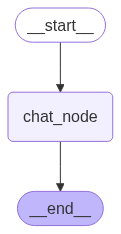

In [10]:
chatbot

### A Single Invocation with a `HumanMessage`

This cell demonstrates the basic call pattern without the input loop. `initial_state` is a dictionary matching the `ChatState` schema: `{'messages': [HumanMessage(content='...')]}`. Wrapping the raw string in `HumanMessage` is what makes it a proper message object the `add_messages` reducer and the chat model both understand, as opposed to a plain string.

`chatbot.invoke(initial_state)` runs the graph once: `chat_node` reads the one-message list, calls the model, and appends the model's `AIMessage` reply. The result is a dictionary with the same `messages` key, now containing both the human message and the AI reply. Indexing `['messages'][-1].content` pulls out the text of the most recent (AI) message — the model's answer to the question.

Note that this call does not pass a `config` with a `thread_id`, so there is no checkpointing tied to a conversation thread here — it is a single, isolated call.


In [11]:
initial_state = {
    'messages': [HumanMessage(content='What is the capital of india')]
}

chatbot.invoke(initial_state)['messages'][-1].content


'The capital of India is New Delhi.'

### The Multi-Turn Conversation Loop

This is where the chatbot becomes an actual back-and-forth conversation. The mechanics:

- `thread_id = '1'` fixes the checkpointer key that all turns in this loop will share. Because `chatbot` was compiled with the `MemorySaver` checkpointer, every `invoke` call made with `config={'configurable': {'thread_id': '1'}}` reads and writes the *same* stored `messages` list rather than starting fresh.
- The `while True` loop reads a line of input, prints it, and checks for an exit keyword (`'exit'`, `'bye'`, `'quit'`) to break out.
- Each surviving turn wraps the raw input string in `HumanMessage` and calls `chatbot.invoke({'messages': [HumanMessage(content=user_message)]}, config=config)`. Only the *new* human message is passed in explicitly — the prior turns are not resupplied by the caller. They are restored automatically from the checkpointer keyed by `thread_id`, then the `add_messages` reducer appends the new human message and the new AI reply on top of that restored history.
- `response['messages'][-1].content` prints just the latest AI reply.

This is what allows the conversation transcript in the cell's output to reference earlier turns correctly (for example, recalling a name given a few turns earlier) — the checkpointer is reconstructing the full history on each call, and the model always sees that whole history via `chat_node`.

The recorded output also shows a kernel crash after the exit keyword is typed. This is an environment/runtime issue with the interactive `input()` loop inside this notebook, not a property of the graph or the checkpointing logic itself.


In [17]:
thread_id = '1'

while True:

    user_message = input('Type here: ')
    print('User: ', user_message)

    if user_message.strip().lower() in ['exit', 'bye', 'quit']:
        break

    config = {'configurable': {'thread_id': thread_id}}

    response = chatbot.invoke({'messages': [HumanMessage(content=user_message)]}, config=config)
    print('AI: ', response['messages'][-1].content)

User:  Hi
AI:  Hello! How can I help you today?
User:  My name is Rohan
AI:  Nice to meet you, Rohan! How can I assist you today?
User:  whats my name?
AI:  Your name is Rohan.
User:  good bye mean?
AI:  "Goodbye" is a polite way to bid farewell or say goodbye to someone.
User:  bye


: 

### Rebuilding After the Kernel Restart

After the earlier kernel crash, this cell rebuilds the same chatbot pattern from scratch in a self-contained cell, under renamed identifiers (`VoiceState` instead of `ChatState`, `llm_service` instead of `chat_node`, `workflow` instead of `chatbot`). The logic is identical to before:

- `load_dotenv()` loads environment variables (such as API keys) needed by `ChatOpenAI`, since this is a fresh kernel session.
- `VoiceState` is the same single-field, `add_messages`-annotated message-list schema as `ChatState`.
- `llm_service` is the same read-state / invoke-model / return-new-message node as `chat_node`.
- A new `MemorySaver` checkpointer is created, and the graph is built with the same `START -> llm_service -> END` edges.
- Notably, `workflow = graph.compile()` here is compiled **without** passing `checkpointer=checkpointer` — the checkpointer object is created but not attached at this point. Displaying `workflow` again renders the same three-node diagram as before, confirming the graph shape is unchanged.


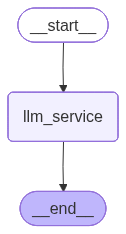

In [12]:
from dotenv import load_dotenv
load_dotenv()

from langgraph.graph import StateGraph, START, END
from typing import TypedDict, Annotated
from langchain_core.messages import BaseMessage, HumanMessage
from langchain_openai import ChatOpenAI
from langgraph.checkpoint.memory import MemorySaver
from langgraph.graph.message import add_messages

class VoiceState(TypedDict):
    messages: Annotated[list[BaseMessage], add_messages]

llm = ChatOpenAI()
def llm_service(state: VoiceState):
    # take user query from state
    messages = state['messages']
    # send to llm
    response = llm.invoke(messages)
    # response store state
    return {'messages': [response]}

# Memory
checkpointer = MemorySaver()
# Graph Foundation
graph = StateGraph(VoiceState)

graph.add_node('llm_service', llm_service)

graph.add_edge(START, 'llm_service')
graph.add_edge('llm_service', END)

workflow = graph.compile()

workflow

### Attaching the Checkpointer with a Second Compile

`chatbot = graph.compile(checkpointer=checkpointer)` recompiles the same underlying `graph` builder, this time passing in the `checkpointer` that was instantiated but left unattached in the previous cell. This produces a new compiled graph object, now bound under the name `chatbot`, with checkpointing enabled — matching the setup used earlier in the notebook. This is what makes the following input loop able to persist history by `thread_id` again.


In [13]:
chatbot = graph.compile(checkpointer=checkpointer)

### Second Run of the Multi-Turn Loop

This repeats the same `thread_id`-scoped `while` loop pattern used earlier, now against the freshly rebuilt and checkpointer-attached `chatbot`. The transcript in the output again shows the model correctly recalling a name given a few turns earlier ("What's my Name?" -> "Your name is Rohan"), confirming that the checkpointer is restoring and accumulating the `messages` list across successive `invoke` calls sharing `thread_id = '1'`, exactly as in the first run of this pattern.


In [14]:
thread_id = '1'

while True:

    user_message = input('Type here: ')
    print('User: ', user_message)

    if user_message.strip().lower() in ['exit', 'bye', 'quit']:
        break

    config = {'configurable': {'thread_id': thread_id}}

    response = chatbot.invoke({'messages': [HumanMessage(content=user_message)]}, config=config)
    print('AI: ', response['messages'][-1].content)

User:  Hello I'm Rohan
AI:  Hello Rohan! How can I assist you today?
User:  What's my Name?
AI:  Your name is Rohan.
User:  bye


## Summary

The basic chatbot pattern demonstrated in this notebook rests on three pieces working together:

1. **A message-list state with an accumulating reducer.** `ChatState`/`VoiceState` hold a single `messages` field annotated with `add_messages`, so every node return appends to the conversation history instead of overwriting it.
2. **One LLM node that always reads the full history.** `chat_node`/`llm_service` takes whatever is currently in `state['messages']`, invokes the chat model on the entire list, and returns the new reply to be appended.
3. **A checkpointer plus a stable `thread_id` driving repeated invocations.** The graph itself has no loop — `START -> node -> END`. The turn-taking behavior comes entirely from an external `while` loop calling `invoke` repeatedly with the same `thread_id`, letting the `MemorySaver` checkpointer restore and extend the stored message list on each call.

This is enough for a conversation to hold together correctly for as long as the Python process and its in-memory checkpointer stay alive. It is not enough for a conversation to survive a process restart, since `MemorySaver` stores everything only in memory — restarting the kernel discards every thread's history, which is exactly what is shown happening after the kernel crash partway through this notebook.

Making conversation history durable across restarts and sessions — persisting checkpoints to disk or an external store instead of memory — is the subject of the next notebook, `10_persistence.ipynb`.
